# Check responsivity to Emotional faces across all (pre)screened contacts for participant
Specifically designed for EmotionTask data <br>

____
**tl;dr** <br>
Generates set of values for all ERPs for group analysis
- Contacts drawn from a montage file
- Pairs of valid contacts labeled with `keep == True` are analyzed
- Bipolar rereferenced signals are preprocessed and noisy trials are ID'd
- Average ERPs are generated for each contact/image type
- ERP scalars are derived for comparison across neural systems/participants<br>
____
**Prerequisites:** <br>
Files
- *montage.csv
- *iEEG.csv
- *events.csv <br>

Code
- numpy
- pandas
- matplotlib
- scipy
- my GRID_lab_python repo (https://github.com/jtmiles/GRID_lab_python)

_**Note on the montage.csv file:**_ <br>
Contacts should have been pre-screened for inclusion prior to running <br>
Functionally, the prescreening adds a `keep` column to the montage file <br>
The keep column is used to determine which contacts from the montage to analyze <br>



### Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import os
import re
from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter
from scipy.ndimage import binary_dilation
from scipy.stats import ttest_1samp
from scipy.stats import false_discovery_control as fdc
import matplotlib.pyplot as plt

from iEEG_utils.loading import read_data
from iEEG_utils.processing import filtering
from iEEG_utils.spike_checks import spike_utils
from iEEG_utils import utils

# instantiate a random number generator
rng = np.random.default_rng()

### notebook specific functions


In [13]:
# notebook specific functions
def template_extrema(template, ixA=0, ixB=1024, max_ix=None):
    '''
    find extrema of average ERP (template)
    
    extrema must exist between ixA and ixB of the template,
    and must occur between two zero crossings
    but template can expand beyond those bounds to resolve zero xing
    '''
    
    if max_ix==None:
        # find the max (index) from the template
        max_ix = np.nanargmax(np.abs(template[ixA:ixB]))+ixA
        
    # find where the zero crossings occur (-/+ transition)
    xings = np.flatnonzero((np.sign(template[:-1])*np.sign(template[1:]))<0)
    
    if sum((xings-max_ix)<0) == 0:
        pre_xing = np.argmin(np.sign(max_ix)*template[:max_ix])
    else:
        # zero-xing prior to peak
        pre_xing = xings[(xings-max_ix)<0][-1]
    
    if sum((xings-max_ix)>0) == 0:
        post_xing = np.argmin(np.sign(max_ix)*template[max_ix:])+max_ix 
    else:
        # zero-xing after peak
        post_xing = xings[(xings-max_ix)>0][0]
      
    return int(pre_xing), int(max_ix), int(post_xing)

def calc_resp(sig_mat,ixA=0,ixB=-1,pk_args=None):
    '''
    function to identify post-stimulus responses from HFB activity

    inputs:
    
      sig_mat = timseries (array, 2-d) of HFB activity derived from neural data
                MUST be organized into trials x samples
                *note* - going to look for zero crossings to identify peak
                        activity, so **signal should be z-scored**, not strictly +

      pk_args = dictionary of peak finding parameters for scipy.findpeaks
                one exception; instead of height there is "hscale", which 
                sets how large a peak must be relative to the max pre-stim value
                to be to be counted (default is 1.0, as large as pre-stim max)
                accepts: "distance", "hscale", "width", and "rel_height" as keys

    returns a dataframe with columns | amp | pre_ix | post_ix | max_ix | for each trial
    '''
    
    if pk_args == None:
        distance = 7
        height = 0.25 # permissive, esp. for single trial, if in stdev
        width = 16
        rel_height = 1
    else:
        distance = pk_args["distance"]
        height = pk_args["height"]
        width = pk_args["width"]
        rel_height = pk_args["rel_height"]  
    pres = []
    maxixs = []
    posts = []
    amps = []
    for t,sig in enumerate(sig_mat):
        pk_ixs,pk_info = find_peaks(sig,distance=distance,height=height,width=width,rel_height=rel_height)
        pk_ixs = pk_ixs[pk_ixs<ixB]
        maxpk = 0
        if len(pk_ixs) > 0:
            for ii,pk_ix in enumerate(pk_ixs):
                # for each peak, return indices of its pre/post zero crossings and maximum
                pre_i, max_i, post_i = template_extrema(sig,ixA=ixA,ixB=ixB,max_ix=pk_ix)
                # calculate mean amp between zero crossings
                pkamp = sig[pre_i:post_i].mean()
                # check whether this peak maximizes mean amplitude between zero crossings
                maxpk = max([maxpk,pkamp])
                # if so, save these indices (for now)
                if pkamp==maxpk:
                    pre_t = pre_i
                    post_t = post_i
                    # looking explicitly for max between zero crossings b/c
                    # max_i can correspond to a lower amp peak additional peak
                    # b/w zero crossings in pk_ixs
                    max_t = np.argmax(sig[pre_i:post_i])+pre_i
            pres.append(pre_t), maxixs.append(max_t), posts.append(post_t)
            amps.append(maxpk)
        else:
            pres.append(np.nan), maxixs.append(np.nan), posts.append(np.nan)
            amps.append(np.nan)
    # create df with parameters from each trial
    return pd.DataFrame({"pre_ix":pres,"post_ix":posts,"max_ix":maxixs,"amp":amps})

def find_spikes(signal, srate, trial_mat, iters, win, amp_mask, n_samps=16, pct_thresh=100):
    '''
    signal (1D array) = bipolar rereferenced signal
    srate (int) = signal sampling rate (likely `resrate` if resampling to common rate)
    trial_mat (2D array) = indices shaped as 2D array (trials x timepts)
                           make sure the timepts only cover the period of interest
                           (e.g., ixA:ixB)
    iters (int) = number of surrogates to generate for line-length maxxing
    win (int) = number of samples to take for rolling sum in line-length calculation
    nsamps (int) = samples to dilate around threshold crossing

    returns: array of ixs where ID'd spikes occur in signal
    '''
    # spike filtering  
    # get null distribution from surrogate line-length maxima
    null_dist = spike_utils.spike_surrogates(signal, trial_mat, iters, win)
    spikeval = np.percentile(null_dist, pct_thresh)
    
    # actual data segments
    spike_mat = filtering.rolling_sum(np.abs(np.diff(signal[trial_mat])),win,axis=-1)
    amp_dist = spike_mat.flatten()
    # use high line-lengths and surrogate derived threshold to find spikes
    lls = filtering.rolling_sum(np.abs(np.diff(np.concat([(bipolar[1],),bipolar]))),win,axis=0)
    ll_thresh = lls>spikeval
    # "dilate" (expand) the mask b/c just a threshold crossing is not always adequate when spikes
    # are relatively small and fast. This expands out by a number of samples
    dilarray = np.ones([n_samps+1,],dtype=bool) # +1 to center ID'd events
    ll_mask = binary_dilation(ll_thresh,structure=dilarray)
    # for fast spikes, the dilation can cause false positives
    # make sure it doesn't add anything < spikeval/2
    ll_mask[lls<(spikeval/2)] = False
    
    # calculate the spike_prominences, filter nearby spikes
    spike_ixs, spike_proms = spike_utils.find_spike_heights(bipolar,ll_mask,win,srate,
                                                            prominence_wlen=int(srate/4),
                                                            min_prominence=None,
                                                            suppress_ratio=1,
                                                            suppress_dist=32)
    
    baseproms = find_peaks(bipolar[((~amp_mask)*(~ll_mask)).astype(bool)],prominence=(0))[1]["prominences"]
    # standard deviations above the average "baseline" prominence (all "peaks" excluding amplitude excursions and ID'd spikes)
    prom_thresh = np.mean(baseproms)+(2*np.nanstd(baseproms))
    # print(prom_thresh)
    
    return spike_ixs[spike_proms>prom_thresh]

# def process_noise(reg_sig, resrate, pre, post, win_dur=0.125, MAD_thresh=8.0, max_dur):
#     '''
#     reg_sig = bipolar rereferenced signal for the region (single region, 1D array of floats)
#     resrate = resampled rate used for bipolar rereferencing
#     pre = pre-stimulus duration (in NEGATIVE seconds, e.g., -0.5)
#     post = post stimulus duration (in seconds, e.g., 1.0)
#     win_dur = duration of window for looking for amplitude excursions (in seconds, default = 0.125)
#     MAD_thresh = median absolute deviations, amplitude excursions above are considered noise (default = 8.0)
#     min_dur = max allowable duration for noise excursions (default = 0.125 same as win_dur)
#     '''

    

### Load data/metadata

In [3]:
# use file selection dialog to choose folder with data
fstr = read_data.select_directory()
print(fstr)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\351f72\EmotionTask


In [4]:
# load each data file

montage = read_data.load_info(fstr,ftype="montage")
montage.name = montage.name.replace(" ","",regex=True)
origfs,data = read_data.load_iEEG(fstr,load_meta=True)
events = read_data.load_info(fstr,ftype="events")
data.columns = data.columns.str.replace(r"\s+", "", regex=True)

try:
    origtime = pd.to_datetime(data.time,format='%H:%M:%S.%f')
except AttributeError:
    origtime = pd.to_datetime(data.index,format='%H:%M:%S.%f')
    
origts = np.array(origtime-origtime[0])/ np.timedelta64(1, 's')

if origfs == None:
    origfs = 1/np.diff(origts).astype("float64").mean()
    print("original sampling frequency not declared, calculated as: "+str(origfs)+" Hz")

montage = montage.loc[(montage.keep)&(montage.region!="DC_sync"),:]

# Align traces to image onsets
img_ts = origts[events.img_on_ix]

# add systems identifiers
limbic = ["hip", "amy", "entorhinal","insula","orbit","cingulate"]
assoc = ["supramarginal","middletemporal","inferiortemporal","temporalpole","supramarginal","parietal","frontal","pars","angular"]
sensmo = ["lingual","cuneus","precentral","postcentral","calcarine","fusiform","superiortemporal"]

systems = []
for r in montage.region:
    if any([limbic[ix] in r.lower() for ix in range(len(limbic))]):
        systems.append("limbic")
    # elif any([frontal[ix] in r.lower() for ix in range(len(frontal))]):
    #     systems.append("frontal")
    elif any([assoc[ix] in r.lower() for ix in range(len(assoc))]):
        systems.append("association")
    elif any([sensmo[ix] in r.lower() for ix in range(len(sensmo))]):
        systems.append("sensorimotor")
    else:
        print("?",r)
        systems.append("?")

montage["system"] = systems

# find valid montage pairs. two right now - will clean once I figure out what this notebook does...
pairs_list = np.array(utils.find_valid_pairs(montage["name"].to_list(),montage["region"].to_list()))
sort_pairs = np.array(utils.find_valid_pairs(montage.sort_values(by=["system","name","ch"]).name.to_list(),
                                             montage.sort_values(by=["system","name","ch"]).region.to_list()))

display(montage)
print(sort_pairs)

,ID,age,region,ch,name,keep,system
8,351f72,10.92,l_lateralorbitofrontal,24,LP1,True,limbic
9,351f72,10.92,l_lateralorbitofrontal,25,LP2,True,limbic
14,351f72,10.92,l_rostralanteriorcingulate,73,LQ2,True,limbic
15,351f72,10.92,l_rostralanteriorcingulate,74,LQ3,True,limbic
19,351f72,10.92,l_parsopercularis,86,LAA3,True,association
20,351f72,10.92,l_parsopercularis,87,LAA4,True,association
24,351f72,10.92,l_precentral,99,LM8,True,sensorimotor
25,351f72,10.92,l_precentral,100,LM9,True,sensorimotor


[['LM8' 'LM9']
 ['LQ2' 'LQ3']
 ['LP1' 'LP2']
 ['LAA3' 'LAA4']]


### calculate and plot the largest amplitude HFB activity from sensorimotor, limbic, and association regions

In [14]:
# do signal processing and extract scalars/ERP per region

# parameters for signal processing
resrate = 1024
# time prior to (pre) and after (post) image onset
pre = -0.5
post = 1
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.25 # seconds
# pk_args for sub-threshold peak finding
pk_params = {"distance": 7,
              "height":0,
              "width":16,
              "rel_height":1}
# response and baseline window durations (equal)
pk_dur = (2/3)
# face-image categories (exludes house images)
img_cats = ["anger","fear","neutral","happy"]

# collect df for each pair for later concatenation
reg_dfs = []
reg_resids = []
for ii,pair in enumerate(sort_pairs):
    reg_ERP = {}
    reg = montage.region[montage.name==pair[0]].item()
    sys = montage.system[montage.name==pair[0]].item()
    reg_ERP["region"] = reg; reg_ERP["system"] = sys
    
    #### re-reference the signal
    ts,bipolar,_ = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,resrate,norm=None)
    #### set up timing info
    # this could be done outside of the loop for the first pair, set for all subsequent
    t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
    # vector of time points aligned to image
    plot_ts = np.linspace(pre,post,t_ixs.shape[1])
    # image onset
    ix0 = min(np.where(plot_ts>=-0)[0]) 
    # setting slightly negative b/c some regions ramp
    ixA = min(np.where(plot_ts>=-0.05)[0]) 
    # restrict peak to 667 ms post onset (not sure if I really want this anymore or not...)
    ixB = min(np.where(plot_ts>=pk_dur)[0])
    # allow signal to be a little longer for peaks to resolve
    ix1 = min(np.where(plot_ts>=1)[0])
    
    #### identify and mask noise
    # see how many trials have amplitude excursions within the ERP window
    norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)
    amp_mask = norm_env>MAD_thresh
    # filter the trials with too many amplitude excursions in the pre/post window
    keep = np.sum(np.int64((amp_mask)[t_ixs]),axis=1)<(min_dur*resrate)
    n_ts = events.loc[keep,:].groupby(by="img_category").block.count()
    # find spikes for filtering
    win = int(resrate/64)
    spike_ixs = find_spikes(bipolar, resrate, t_ixs[keep,:], 10000, win, amp_mask, n_samps=16, pct_thresh=99)
    filt_spikes = sorted(set(np.ravel([np.arange(ix-int(win/2),ix+int(win/2),dtype=int) for ix in spike_ixs])))
    
    #### grab baseline periods
    # grab from the period before fixation cross (assuming "pre" is -0.5) as baseline
    base_ixs = np.array(t_ixs[(events.img_category!="house")&(keep),:int(pk_dur*resrate)]-int(pk_dur*resrate),dtype=int)
    #### high frequency broadband calculation
    HFB = np.abs(hilbert(filtering.bfilt(bipolar, resrate, 4, [70, 150], "bandpass")))
    HFB[amp_mask] = np.nan
    HFB[filt_spikes] = np.nan
    signal = gaussian_filter(filtering.zscore(HFB, robust=True),3)
    
    #### calculate dependent variables - all trials
    # noise_ts = np.linspace(0,base_ixs.shape[-1]/resrate,base_ixs.shape[-1])
    noisedf = calc_resp(signal[base_ixs],ixA=0,ixB=base_ixs.shape[-1],pk_args=pk_params)
    respdf = calc_resp(signal[t_ixs[(events.img_category!="house")&(keep),ixA:ix1]],ixB=ixB-ixA,pk_args=pk_params)
    # ratio of image-evoked HFB compared to immediately preceding baseline period
    amprat = np.log2(respdf.amp/noisedf.amp)
    # correcting trials where most of baseline or response period were ID'd as noise/spikes
    amprat[np.isinf(amprat)] = np.nan
    # this is really just diagnostic... not using as a dependent variable
    t_res = ttest_1samp(amprat,popmean=0,alternative="greater", nan_policy="omit")
    
    #### get the ERP and amplitude info
    # # this is currently just for making plots - not used later for any tests
    # ERP_tfilt = np.nanmean(signal[t_ixs[(events.img_category!="house") & (keep),:]],axis=0)
    # # again, not used at all later, but, fyi - peak amp here is avg above session mean, not instantaneous amp of peak
    # ERPdf = calc_resp(ERP_tfilt[np.newaxis,ix0-64:ixB],pk_args=pk_params)
    
    #### compile save data
    reg_ERP["ERP"] = [ERP_tfilt] # not really needed - not going to save
    reg_ERP["amplitude"] = amprat.mean() # OLD = ERPdf.amp.item()
    reg_ERP["contacts"] = f"{pair[1]}-{pair[0]}"
    reg_ERP["t"] = t_res.statistic
    reg_ERP["p"] = t_res.pvalue
    reg_ERP["pct_greater"] = np.nanmean(respdf.amp>noisedf.amp)
    # add dict to list of dfs for concatenation
    reg_dfs.append(pd.DataFrame.from_dict(reg_ERP))
    # do the same for residualized comparison to neutral
    testdf = pd.DataFrame({"amp_ratio":amprat.to_numpy(),"img":events.img_category[(events.img_category!="house")&(keep)].to_list()})
    avgs = testdf.groupby(by="img").mean()
    resids = avgs.amp_ratio-avgs.amp_ratio[avgs.index=='neutral'].item()
    resids.name = reg
    reg_resids.append(resids.to_frame())
    
ERP_df = pd.concat(reg_dfs,ignore_index=True)
ERP_df["ID"] = montage.ID.unique()[0]
ERP_df["age"] = montage.age.unique()[0].astype(np.float64)

display(ERP_df)
# quick FDR correction here (BH), but probably actually want to save raw and correct later...
print(fdc(ERP_df['p'], method='bh'))



not normalizing
not normalizing
not normalizing
not normalizing


,region,system,ERP,amplitude,contacts,t,p,pct_greater,ID,age
0,l_precentral,sensorimotor,"[0.2945367222106026, 0.3106540051077552, 0.328...",0.075685,LM9-LM8,1.221879,1.123883e-01,0.479167,351f72,10.92
1,l_rostralanteriorcingulate,limbic,"[0.415880278471451, 0.4408875219272641, 0.4568...",-0.075575,LQ3-LQ2,-1.231871,8.893969e-01,0.384615,351f72,10.92
2,l_lateralorbitofrontal,limbic,"[0.14841728036451166, 0.14747302009571658, 0.1...",0.069385,LP2-LP1,0.689515,2.460899e-01,0.562500,351f72,10.92
3,l_parsopercularis,association,"[0.07130691227807975, 0.0307785240462322, -0.0...",0.558938,LAA4-LAA3,7.380169,3.786641e-11,0.791209,351f72,10.92


[2.24776552e-01 8.89396859e-01 3.28119824e-01 1.51465632e-10]


### save data

In [6]:
suffix = r"HFBdata.csv"
savestr = fstr+fr"\EmotionTask_{montage.ID.unique()[0]}_{suffix}"
print(savestr)
ERP_df[["ID","age","region","contacts","amplitude","t","p","pct_greater"]].to_csv(savestr,index=False)

# trialstr = fstr+fr"\EmotionTask_{montage.ID.unique()[0]}_Trial{suffix}"
# trials_df[["ID","age","region","contacts","amp","latency","duration","responsive","category"]].to_csv(trialstr,index=False)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\351f72\EmotionTask\EmotionTask_351f72_HFBdata.csv


In [20]:
# fig 1 plot set-up (data in fig 1 from ID a7ab76)
sysmaxs = ERP_df.groupby(by="system").agg({"amplitude":"max"})
maxdf = ERP_df.loc[np.isin(ERP_df.amplitude,sysmaxs.amplitude.to_numpy()),:]
# run again with max from each system, plot heatmap of all trials
plotmaps = np.isin([f"{sort_pairs[ix][1]}-{sort_pairs[ix][0]}" for ix in range(len(sort_pairs))],maxdf.contacts.to_list())

# cmaps for coloring distinct category heatmaps
cmaps = [plt.cm.Blues,plt.cm.Oranges,plt.cm.Greys]

# set up figure
# stack ERPs by region, categories by column
#### NOTE
#### May also make sense to plot as colormesh, with colormap tone shifted by system
fig,ax = plt.subplots(2,sum(plotmaps),figsize=[6.5,3],sharex=True,
                      gridspec_kw={'height_ratios': [1,3]})
# no spacing between rows, some spacing between columns
fig.subplots_adjust(hspace=0, wspace=0.05)
sort_reg = []
for ii,pair in enumerate(sort_pairs[plotmaps]):
    reg = montage.region[montage.name==pair[0]].item()
    sort_reg.append(reg)
    # set plot color
    sys = montage.system[montage.name==pair[0]].item()
    match sys:
        case "sensorimotor":
            c = np.array([0, 88, 111])/255 # dblue
            cmap = cmaps[0]
        case "limbic":
            c = np.array([162, 82, 48])/255 # dorange
            cmap = cmaps[1]
        case "association":
            c = np.array([74, 79, 85])/255 # dgrey
            cmap = cmaps[2]
    # re-reference the signal
    ts,bipolar,_ = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,resrate,norm=None)
    # this could be done outside of the loop for the first pair, set for all subsequent
    t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
    plot_ts = np.linspace(pre,post,t_ixs.shape[1])
    # image onset
    ix0 = min(np.where(plot_ts>=-0.1)[0]) # setting slightly negative b/c some regions ramp 
    # # this is just the first timepoint - shouldn't need
    # ixA = min(np.where(plot_ts>=-0.50)[0])
    # restrict to 667 ms post onset (not sure if I really want this anymore or not...)
    ixB = min(np.where(plot_ts>=0.667)[0])
    # identify and mask noise
    # see how many trials have amplitude excursions within the ERP window
    norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)
    amp_mask = norm_env>MAD_thresh
    # filter the trials with too many amplitude excursions in the pre/post window
    keep = np.sum(np.int64((amp_mask)[t_ixs]),axis=1)<(min_dur*resrate)
    n_ts = events.loc[keep,:].groupby(by="img_category").block.count()
    # find spikes for filtering
    win = int(resrate/64)
    spike_ixs = find_spikes(bipolar, resrate, t_ixs[keep,:], 10000, win, amp_mask, n_samps=16)
    filt_spikes = sorted(set(np.ravel([np.arange(ix-int(win/2),ix+int(win/2),dtype=int) for ix in spike_ixs])))

    HFB = np.abs(hilbert(filtering.bfilt(bipolar, resrate, 4, [70, 150], "bandpass")))
    HFB[amp_mask] = np.nan
    HFB[filt_spikes] = np.nan
    signal = gaussian_filter(filtering.zscore(HFB, robust=True),3)
    
    # regional avg
    ERP_mat = signal[t_ixs[(events.img_category!="house") & (keep),:]]
    reg_ERP = np.nanmean(ERP_mat,axis=0)
    # ERP calculations
    reg_dfs = []
    avg_ERPs = np.zeros([resrate,len(img_cats)])
    vmin = np.percentile(ERP_mat[~np.isnan(ERP_mat)].flatten(),5)
    vmax = np.percentile(ERP_mat[~np.isnan(ERP_mat)].flatten(),95)

    # plot avg on top
    ax[0,ii].plot(plot_ts, np.nanmean(ERP_mat,axis=0), color=c, lw=1.25)
    ax[1,ii].pcolormesh(plot_ts, range(ERP_mat.shape[0]), ERP_mat,
                        cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest")
    # ax[0,ii].plot([0,0], ax[0,ii].get_ylim(), color=[0.3,0.3,0.3], lw=1, ls=":")
ylims= ()
ylims = np.array([ylims+ax[0,ix].get_ylim() for ix in range(ax.shape[-1])]   )
[ax[0,ix].plot([0,0],[ylims.min(),ylims.max()],color=[0.25,0.25,0.25,0.75],ls=":") for ix in range(ax.shape[-1])]      
[ax[aa,bb].set_axis_off() for aa in range(ax.shape[0]) for bb in range(ax.shape[1])]
plt.show()


NameError: name 'ERP_df' is not defined

,region,system,ERP,amplitude,contacts,t,p,pct_greater,ID,age
2,l_lateralorbitalfrontal,limbic,"[-0.057745158413521264, -0.07389962795952985, ...",0.145256,LO6-LO5,2.929494,1.906585e-03,0.552632,c66248,9.08
5,r_rostralmiddlefrontal,association,"[-0.24484879226667527, -0.23891266991371826, -...",0.354463,RH14-RH13,7.161604,8.626001e-12,0.663158,c66248,9.08


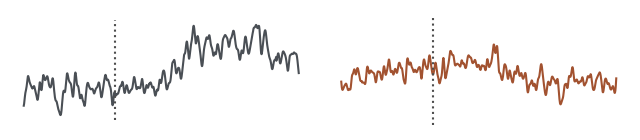

In [80]:
# fig 1 plot set-up
# just ERPS - cell below plots with individual trial heatmaps
fig,ax = plt.subplots(1,len(ERP_df.system.unique()),figsize=(6.5,1.5), sharey=True, layout="tight")
sysmaxs = ERP_df.groupby(by="system").agg({"amplitude":"max"})
maxdf = ERP_df.loc[np.isin(ERP_df.amplitude,sysmaxs.amplitude.to_numpy()),:]
display(maxdf)
bline = np.zeros(len(plot_ts))
for ix in range(len(sysmaxs)):
    sys = sysmaxs.iloc[ix,:].name
    match sys:
        case "sensorimotor":
            c = np.array([0, 88, 111])/255 # dblue
        case "limbic":
            c = np.array([162, 82, 48])/255 # dorange
        case "association":
            c = np.array([74, 79, 85])/255 # dgrey
    bigERP = np.array(ERP_df.ERP[ERP_df.amplitude==sysmaxs.amplitude.iloc[ix]].item())
    ax[ix].plot(plot_ts,bigERP,color=c)
    # ax[ix].plot(plot_ts,bline,ls=":",color=[0.3,0.3,0.3])
    ax[ix].plot([0,0],ax[ix].get_ylim(),ls=":",color=[0.3,0.3,0.3])
    ax[ix].axis("off")
plt.show()

In [7]:
# do a bit of investigating the individual trial HFBs
# Align traces to image onsets

img_ts = origts[events.img_on_ix]

ch_list = montage.name.to_list()

# create a dropdown to choose region to analyze
all_reg = montage.region.unique()
dropdown = utils.dropdown_select(all_reg)



Dropdown(description='Choose region:', options=('l_lateralorbitofrontal', 'l_rostralanteriorcingulate', 'l_par…

In [15]:
# parameters for signal processing
resrate = 1024
# time prior to (pre) and after (post) image onset
pre = -0.5
post = 1
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds
# pk_args for sub-threshold peak finding
pk_params = {"distance": 7,
              "height":0,
              "width":16,
              "rel_height":1}

In [22]:
reg = dropdown.value
conts = montage.name[montage.region==reg].to_list()
testpair = sort_pairs[sort_pairs==conts]

#### re-reference the signal
ts,bipolar,_ = filtering.bipolar_reref(data.loc[:,testpair[::-1]],origfs,resrate,norm=None)
#### set up timing info
# this could be done outside of the loop for the first pair, set for all subsequent
t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
# vector of time points aligned to image
plot_ts = np.linspace(pre,post,t_ixs.shape[1])
# image onset
ix0 = min(np.where(plot_ts>=-0)[0]) 
# setting slightly negative b/c some regions ramp
ixA = min(np.where(plot_ts>=-0.05)[0]) 
# restrict peak to 667 ms post onset (not sure if I really want this anymore or not...)
ixB = min(np.where(plot_ts>=0.667)[0])
# allow signal to be a little longer for peaks to resolve
ix1 = min(np.where(plot_ts>=1)[0])

#### identify and mask noise
# see how many trials have amplitude excursions within the ERP window
norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)
amp_mask = norm_env>MAD_thresh
# filter the trials with too many amplitude excursions in the pre/post window
keep = np.sum(np.int64((amp_mask)[t_ixs]),axis=1)<(min_dur*resrate)
n_ts = events.loc[keep,:].groupby(by="img_category").block.count()
# find spikes for filtering
win = int(resrate/64)
spike_ixs = find_spikes(bipolar, resrate, t_ixs[keep,:], 10000, win, amp_mask, n_samps=16, pct_thresh=99)
filt_spikes = sorted(set(np.ravel([np.arange(ix-int(win/2),ix+int(win/2),dtype=int) for ix in spike_ixs])))

#### grab baseline periods
# grab from the baseline period before fixation cross (assuming "pre" is -0.5) as baseline
base_ixs = np.array(t_ixs[(events.img_category!="house")&(keep),:int(pk_dur*resrate)]-int(pk_dur*resrate),dtype=int)
#### high frequency broadband calculation
HFB = np.abs(hilbert(filtering.bfilt(bipolar, resrate, 4, [70, 150], "bandpass")))
HFB[amp_mask] = np.nan
HFB[filt_spikes] = np.nan
signal = gaussian_filter(filtering.zscore(HFB, robust=True),3)

#### calculate dependent variables - all trials
noise_ts = np.linspace(0,base_ixs.shape[-1]/resrate,base_ixs.shape[-1])
noisedf = calc_resp(signal[base_ixs],ixA=0,ixB=base_ixs.shape[-1],pk_args=pk_params)
respdf = calc_resp(signal[t_ixs[(events.img_category!="house")&(keep),ixA:ix1]],ixB=ixB-ixA,pk_args=pk_params)


not normalizing


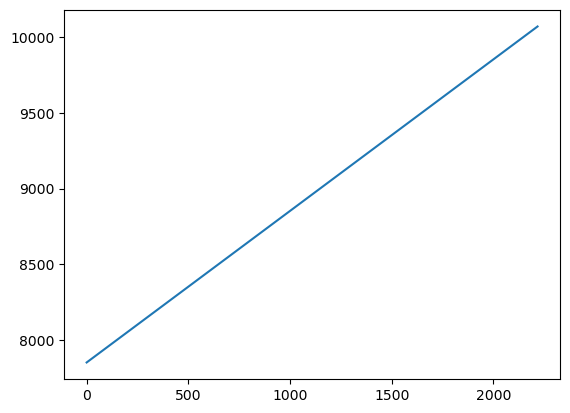

In [29]:
bline_ixs = np.concat([base_ixs,t_ixs[(events.img_category!="house")&(keep),:]],axis=-1)


In [33]:
bline_ixs.shape

(87, 2218)

68
-0.042053738740719875


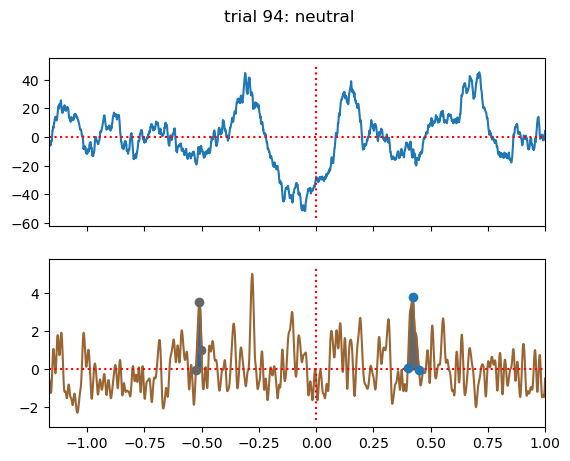

In [63]:
# check baseline/response HFB comparison
# rms_sig = np.sqrt(filtering.rolling_sum(signal,int(resrate/32))**2/(resrate/32))[t_ixs[(events.img_category!="house")&(keep),:]]
bline_ixs = np.concat([base_ixs,t_ixs[(events.img_category!="house")&(keep),:]],axis=-1)
bline_ts = np.linspace(pre-pk_dur,1,bline_ixs.shape[-1])

keepts = events[(events.img_category!="house")&(keep)].index.to_list()
randix = rng.integers(low=0,high=len(keepts))
print(randix)
sig = signal[bline_ixs[randix,:]]
bip = bipolar[bline_ixs[randix,:]]
# rms_t = rms_sig[randix,:]
resp_ixs = ixA+np.array([respdf.pre_ix[randix],respdf.max_ix[randix],respdf.post_ix[randix]], dtype=int)+sum(bline_plot<-0.5)
bline_pks = np.array([noisedf.pre_ix[randix],noisedf.max_ix[randix],noisedf.post_ix[randix]], dtype=int)

print(np.log2(respdf.amp[randix]/noisedf.amp[randix]))
fig,ax = plt.subplots(2,1, sharex=True)
ax[0].plot(bline_ts,bip)
ax[1].scatter(bline_ts[resp_ixs],sig[resp_ixs],color="C0",zorder=3)
ax[1].scatter(bline_ts[bline_pks],sig[bline_pks],color=[0.4,0.4,0.4],zorder=3)
ax[1].plot(bline_ts,sig,color=[0.6,0.4,0.2,1])
ax[1].fill_between(bline_ts[resp_ixs[0]:resp_ixs[-1]],sig[resp_ixs[0]:resp_ixs[-1]],y2=np.zeros(resp_ixs[-1]-resp_ixs[0]),color=[0.4,0.4,0.4])
ax[1].fill_between(bline_ts[bline_pks[0]:bline_pks[-1]],sig[bline_pks[0]:bline_pks[-1]],y2=np.zeros(bline_pks[-1]-bline_pks[0]),color=[0.2,0.4,0.6])
fig.suptitle(f"trial {keepts[randix]}: {events.img_category[keepts[randix]]}")

# ax1 = ax[1].twinx()
# ax[1].plot(plot_ts, rms_t, color=[0.4,0.8,0.6])
ax[0].set_xlim([pre-pk_dur,1])
[ax[ix].plot([0,0], ax[ix].get_ylim(),"r:") for ix in range(ax.shape[0])]
[ax[ix].plot(ax[ix].get_xlim(),[0,0],"r:") for ix in range(ax.shape[0])]
plt.show()

### bunch of tests and other figures below... will need to delete someday!

not normalizing
not normalizing
not normalizing
not normalizing


C:\Users\jmile3\AppData\Local\Temp\ipykernel_15716\520517445.py:89: RuntimeWarning: All-NaN slice encountered
  base_maxs = np.nanmax(signal[base_ixs],axis=-1)


not normalizing
not normalizing
not normalizing
not normalizing
not normalizing


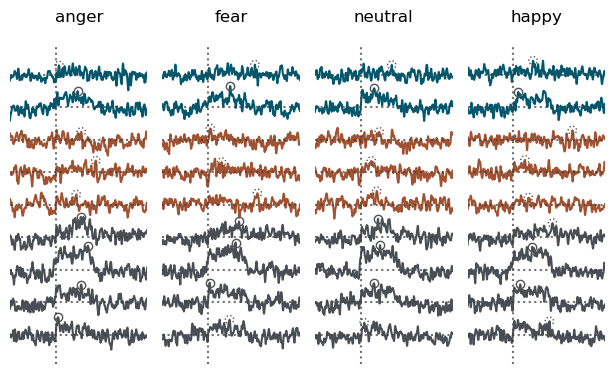

In [128]:
# compact responsivity figure

# ERPs or high-frequency broadband activity? (set True for HFB)
HFB_calc = True

# parameters for signal processing
resrate = 1024
# time prior to (pre) and after (post) image onset
pre = -0.5
post = 1
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds
# pk_args for sub-threshold peak finding
subpks_dict = {"distance": 7,
               "hscale":0.5,
               "width":16,
               "rel_height":1}

img_cats = ["anger","fear","neutral","happy"]

# for noise "ceiling" calculation
n_sub = 48
n_iters = 10000

# set up figure
# stack ERPs by region, categories by column
#### NOTE
#### May also make sense to plot as colormesh, with colormap tone shifted by system
fig,ax = plt.subplots(1,len(img_cats),figsize=[6.25,4], tight_layout=True, sharey=True)
# multiplier for spacing between regions
spacer = -1
# collect df for each pair for later concatenation
reg_list = []
trialsbyreg = []
for ii,pair in enumerate(sort_pairs):
    reg = montage.region[montage.name==pair[0]].item()
    # set plot color
    sys = montage.system[montage.name==pair[0]].item()
    match sys:
        case "sensorimotor":
            c = np.array([0, 88, 111])/255 # dblue
        case "limbic":
            c = np.array([162, 82, 48])/255 # dorange
        case "association":
            c = np.array([74, 79, 85])/255 # dgrey

    # re-reference the signal
    ts,bipolar,_ = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,resrate,norm=None)
    # this could be done outside of the loop for the first pair, set for all subsequent
    t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
    plot_ts = np.linspace(pre,post,t_ixs.shape[1])
    # image onset
    ix0 = min(np.where(plot_ts>=-0.1)[0]) # setting slightly negative b/c some regions ramp 
    # # this is just the first timepoint - shouldn't need
    # ixA = min(np.where(plot_ts>=-0.50)[0])
    # restrict to 667 ms post onset (not sure if I really want this anymore or not...)
    ixB = min(np.where(plot_ts>=0.667)[0])
    # identify and mask noise
    # see how many trials have amplitude excursions within the ERP window
    norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)
    amp_mask = norm_env>MAD_thresh
    # filter the trials with too many amplitude excursions in the pre/post window
    keep = np.sum(np.int64((amp_mask)[t_ixs]),axis=1)<(min_dur*resrate)
    n_ts = events.loc[keep,:].groupby(by="img_category").block.count()
    # find spikes for filtering
    win = int(resrate/64)
    spike_ixs = find_spikes(bipolar, resrate, t_ixs[keep,:], 10000, win, amp_mask, n_samps=16)
    filt_spikes = sorted(set(np.ravel([np.arange(ix-int(win/2),ix+int(win/2),dtype=int) for ix in spike_ixs])))
    # print(f"Number of spikes: {len(spike_ixs)}")

    # high frequency broadband calculation
    if HFB_calc:
        HFB = np.log(np.abs(hilbert(filtering.bfilt(bipolar, resrate, 4, [70, 150], "bandpass"))))
        HFB[amp_mask] = np.nan
        HFB[filt_spikes] = np.nan
        signal = gaussian_filter(filtering.zscore(HFB),3)
        # set the noise threshold for image evoked peak identification
        # grab from the 0.5 sec before fixation cross (assuming "pre" is -0.5)
        base_ixs = np.array(t_ixs[:,:int(resrate/2)]-int(resrate/2),dtype=int)
        # generate a bootstrap null distribution of baseline max amplitudes
        # grab n_sub (roughly the number of image presentations) trials, n_iters times
        t_samps = rng.integers(low=0, high=base_ixs.shape[0],size=n_sub*n_iters)
        # average across the 40 random trials,then take the max of the average trace
        noise_dist = np.nanmean(np.reshape(signal[base_ixs[t_samps,:]],(n_sub,base_ixs.shape[-1],n_iters)),axis=0).max(axis=0).squeeze()
        noise_thresh = np.percentile(noise_dist,95)
        # for trial-wise, can't bootstrap, so base empirically on max across trials 
        base_maxs = np.nanmax(signal[base_ixs],axis=-1)
        trial_thresh = np.percentile(base_maxs,95)
    else:
        signal = bipolar

    # ERP calculations
    reg_dfs = []
    avg_ERPs = np.zeros([resrate,len(img_cats)])
    # this will be kinda massive...
    reg_trials = []
    for ix,cat in enumerate(img_cats):
        # just looking at the ERP here
        ERP_tfilt = np.nanmean(signal[t_ixs[(events.img_category==cat)&(keep),:]],axis=0)
        ERPdf = calc_resp(ERP_tfilt[np.newaxis,:],plot_ts,ix0,ixB,pk_args=None,height=noise_thresh)
        # try calc for all individual trials...?
        trialdf = calc_resp(signal[t_ixs[(events.img_category==cat)&(keep),:]],
                            plot_ts,ix0,ixB,pk_args=None, height=noise_thresh)
        trialdf["responsive"] = trialdf.amp>trial_thresh
        # make sure if peaks are before image onset that the zero-crossing resolves
        # after image onset. otherwise, likely just noise peaks and not from ramping activity
        if ERPdf.isna().all(axis=1).item() or ((ERPdf.max_ix.item()<0) & (ERPdf.post.item()<0)):
            # if there were no eligible peaks, re-run but flag as not responsive.
            # point is to ensure some value is chosen, even if small, so downstream calculations
            # can still use these data
            ERPdf = calc_resp(ERP_tfilt[np.newaxis,:],plot_ts,ix0,ixB,pk_args=subpks_dict)
            ERPdf["responsive"] = False
        else:
            ERPdf["responsive"] = True
        
        # plot each column
        ax[ix].plot(plot_ts, ERP_tfilt+(ii*spacer), color=c)
        ax[ix].plot(plot_ts[[0,-1]],(ii*spacer)*np.ones((2,)),color=[0.25,0.25,0.25,0.75],ls=":")
        if ERPdf.responsive.item():
            ls = "-"
        else:
            ls = ":"
        ax[ix].scatter(plot_ts[ERPdf.max_ix.item()],ERP_tfilt[ERPdf.max_ix.item()]+(ii*spacer),
                       edgecolor=[0.33,0.33,0.33],facecolor=[1,1,1,0],zorder=2, ls=ls)
        # add a flag for the image category
        ERPdf["category"] = cat
        trialdf["category"] = cat
        reg_trials.append(trialdf)
        reg_dfs.append(ERPdf)
        # collect the first second of data after image presentation
        # going to use it to make compare correlation between ERPs
        avg_ERPs[:,ix] = ERP_tfilt[ix0:(ix0+resrate)] 
        
    ERP_corrs = np.triu(np.corrcoef(avg_ERPs,rowvar=False),k=1)
    pair_corrs = ERP_corrs[np.nonzero(ERP_corrs)].mean()
        
    [ax[ix].set_xlim([-0.5,1]) for ix in range(len(img_cats))]

    # group dataframes across categories
    reg_df = pd.concat(reg_dfs,ignore_index=True)
    trials_df = pd.concat(reg_trials,ignore_index=True)
    reg_df["ERP_corr"] = pair_corrs
    reg_df["region"] = reg
    reg_df["contacts"] = pair[1]+"-"+pair[0]
    trials_df["region"] = reg
    trials_df["contacts"] = pair[1]+"-"+pair[0]
    reg_list.append(reg_df)
    trialsbyreg.append(trials_df)
    
ylims = ax[-1].get_ylim()    
[ax[ix].plot([0,0],ylims,color=[0.25,0.25,0.25,0.75],ls=":") for ix in range(len(img_cats))]   
[ax[ix].set_axis_off() for ix in range(len(img_cats))]
[ax[ix].set_title(cat) for ix,cat in enumerate(img_cats)]
plt.show()

ERP_df = pd.concat(reg_list,ignore_index=True)
ERP_df["ID"] = montage.ID.unique()[0]
ERP_df["age"] = montage.age.unique()[0].astype(np.float64)
trials_df = pd.concat(trialsbyreg,ignore_index=True)
trials_df["ID"] = montage.ID.unique()[0]
trials_df["age"] = montage.age.unique()[0].astype(np.float64)


not normalizing
not normalizing
not normalizing
not normalizing
not normalizing
not normalizing
not normalizing
not normalizing
not normalizing
not normalizing


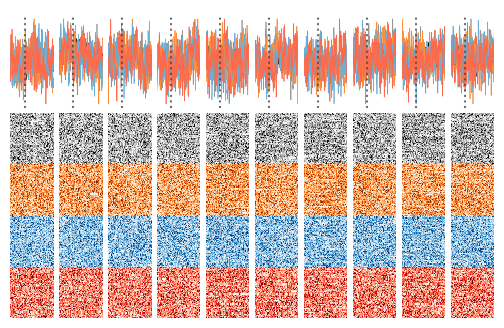

In [10]:
# compact responsivity figure

# ERPs or high-frequency broadband activity? (set True for HFB)
HFB_calc = True

# parameters for signal processing
resrate = 1024
# time prior to (pre) and after (post) image onset
pre = -0.5
post = 1
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds
# pk_args for sub-threshold peak finding
subpks_dict = {"distance": 7,
               "hscale":0.5,
               "width":16,
               "rel_height":1}

img_cats = ["anger","fear","neutral","happy"]

# cmaps for coloring distinct category heatmaps
cmaps = [plt.cm.Greys_r,plt.cm.Oranges_r,plt.cm.Blues_r,plt.cm.Reds_r]

# set up figure
# stack ERPs by region, categories by column
#### NOTE
#### May also make sense to plot as colormesh, with colormap tone shifted by system
fig,ax = plt.subplots(len(img_cats)+1,len(sort_pairs),figsize=[6.25,4], sharex=True,
                      gridspec_kw={'height_ratios': [1]+list(0.5*np.ones(len(img_cats)))})
# no spacing between rows, some spacing between columns
fig.subplots_adjust(hspace=0, wspace=0.125)

# multiplier for spacing between regions
spacer = -1
# collect df for each pair for later concatenation
reg_list = []
trialsbyreg = []
sort_reg = []
for ii,pair in enumerate(sort_pairs):
    reg = montage.region[montage.name==pair[0]].item()
    sort_reg.append(reg)
    # set plot color
    sys = montage.system[montage.name==pair[0]].item()
    match sys:
        case "sensorimotor":
            c = np.array([0, 88, 111])/255 # dblue
        case "limbic":
            c = np.array([162, 82, 48])/255 # dorange
        case "association":
            c = np.array([74, 79, 85])/255 # dgrey

    # re-reference the signal
    ts,bipolar,_ = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,resrate,norm=None)
    # this could be done outside of the loop for the first pair, set for all subsequent
    t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
    plot_ts = np.linspace(pre,post,t_ixs.shape[1])
    # image onset
    ix0 = min(np.where(plot_ts>=-0.1)[0]) # setting slightly negative b/c some regions ramp 
    # # this is just the first timepoint - shouldn't need
    # ixA = min(np.where(plot_ts>=-0.50)[0])
    # restrict to 667 ms post onset (not sure if I really want this anymore or not...)
    ixB = min(np.where(plot_ts>=0.667)[0])
    # identify and mask noise
    # see how many trials have amplitude excursions within the ERP window
    norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)
    amp_mask = norm_env>MAD_thresh
    # filter the trials with too many amplitude excursions in the pre/post window
    keep = np.sum(np.int64((amp_mask)[t_ixs]),axis=1)<(min_dur*resrate)
    n_ts = events.loc[keep,:].groupby(by="img_category").block.count()
    # find spikes for filtering
    win = int(resrate/64)
    spike_ixs = find_spikes(bipolar, resrate, t_ixs[keep,:], 10000, win, amp_mask, n_samps=16)
    filt_spikes = sorted(set(np.ravel([np.arange(ix-int(win/2),ix+int(win/2),dtype=int) for ix in spike_ixs])))
    # print(f"Number of spikes: {len(spike_ixs)}")

    # high frequency broadband calculation
    if HFB_calc:
        HFB = np.log(np.abs(hilbert(filtering.bfilt(bipolar, resrate, 4, [70, 150], "bandpass"))))
        HFB[amp_mask] = np.nan
        HFB[filt_spikes] = np.nan
        signal = gaussian_filter(filtering.zscore(HFB),3)
        # set the noise threshold for image evoked peak identification
        # grab from the 0.5 sec before fixation cross (assuming "pre" is -0.5)
        base_ixs = np.array(t_ixs[:,:int(resrate/2)]-int(resrate/2),dtype=int)
        # generate a bootstrap null distribution of baseline max amplitudes
        # grab n_sub (roughly the number of image presentations) trials, n_iters times
        # t_samps = rng.integers(low=0, high=base_ixs.shape[0],size=n_sub*n_iters)
        # # average across the 40 random trials,then take the max of the average trace
        # noise_dist = np.nanmean(np.reshape(signal[base_ixs[t_samps,:]],(n_sub,base_ixs.shape[-1],n_iters)),axis=0).max(axis=0).squeeze()
        # noise_thresh = np.percentile(noise_dist,95)
        # for trial-wise, can't bootstrap, so base empirically on max across trials 
        base_maxs = np.nanmax(signal[base_ixs],axis=-1)
        trial_thresh = np.percentile(base_maxs,95) 
    else:
        signal = bipolar
    # regional avg
    ERP_mat = signal[t_ixs[keep,:]]
    reg_ERP = np.nanmean(ERP_mat,axis=0)
    ax[0,ii].plot(plot_ts, reg_ERP, color="k") 
    # ERP calculations
    reg_dfs = []
    avg_ERPs = np.zeros([resrate,len(img_cats)])
    vmin = np.percentile(ERP_mat[~np.isnan(ERP_mat)].flatten(),2.5)
    vmax = np.percentile(ERP_mat[~np.isnan(ERP_mat)].flatten(),97.5)
    # this will be kinda massive...
    reg_trials = []
    for ix,cat in enumerate(img_cats):
        # all (clean) instances of category
        catmat = ERP_mat[(events.img_category==cat)[keep],:]
        # just looking at the ERP here
        ERP_tfilt = np.nanmean(catmat,axis=0)
        ERPdf = calc_resp(ERP_tfilt[np.newaxis,:],plot_ts,ix0,ixB,pk_args=None,height=trial_thresh/2)
        # try calc for all individual trials...?
        trialdf = calc_resp(catmat,plot_ts,ix0,ixB,pk_args=None,height=trial_thresh/2)
        trialdf["responsive"] = trialdf.amp>trial_thresh
        # make sure if peaks are before image onset that the zero-crossing resolves
        # after image onset. otherwise, likely just noise peaks and not from ramping activity
        if ERPdf.isna().all(axis=1).item() or ((ERPdf.max_ix.item()<0) & (ERPdf.post.item()<0)):
            # if there were no eligible peaks, re-run but flag as not responsive.
            # point is to ensure some value is chosen, even if small, so downstream calculations
            # can still use these data
            ERPdf = calc_resp(ERP_tfilt[np.newaxis,:],plot_ts,ix0,ixB,pk_args=subpks_dict)
            ERPdf["responsive"] = False
        else:
            ERPdf["responsive"] = True
        
        # plot avg on top
        ax[0,ii].plot(plot_ts, ERP_tfilt, color=cmaps[ix](int(cmaps[ix].N/2)), lw=0.5) 
        ax[ix+1,ii].pcolormesh(plot_ts, range(catmat.shape[0]), catmat,
                             cmap=cmaps[ix], vmin=vmin, vmax=vmax, shading="nearest")
        # add a flag for the image category
        ERPdf["category"] = cat
        trialdf["category"] = cat
        reg_trials.append(trialdf)
        reg_dfs.append(ERPdf)
        # collect the first second of data after image presentation
        # going to use it to make compare correlation between ERPs
        avg_ERPs[:,ix] = ERP_tfilt[ix0:(ix0+resrate)] 
        
    ERP_corrs = np.triu(np.corrcoef(avg_ERPs,rowvar=False),k=1)
    pair_corrs = ERP_corrs[np.nonzero(ERP_corrs)].mean()
        
    [ax[ix+1,ii].set_xlim([-0.5,1]) for ix in range(len(img_cats))]

    # group dataframes across categories
    reg_df = pd.concat(reg_dfs,ignore_index=True)
    trials_df = pd.concat(reg_trials,ignore_index=True)
    reg_df["ERP_corr"] = pair_corrs
    reg_df["region"] = reg
    reg_df["contacts"] = pair[1]+"-"+pair[0]
    trials_df["region"] = reg
    trials_df["contacts"] = pair[1]+"-"+pair[0]
    reg_list.append(reg_df)
    trialsbyreg.append(trials_df)
    
ylims= ()
ylims = [ylims+ax[0,ix].get_ylim() for ix in range(ax.shape[-1])]   
[ax[0,ix].plot([0,0],ylims[ix],color=[0.25,0.25,0.25,0.75],ls=":") for ix in range(ax.shape[-1])]   
[ax[aa,bb].set_axis_off() for aa in range(ax.shape[0]) for bb in range(ax.shape[1])]
# [ax[0,ix].set_title(reg) for ix,cat in enumerate(sort_reg)]
plt.show()

ERP_df = pd.concat(reg_list,ignore_index=True)
ERP_df["ID"] = montage.ID.unique()[0]
ERP_df["age"] = montage.age.unique()[0].astype(np.float64)
trials_df = pd.concat(trialsbyreg,ignore_index=True)
trials_df["ID"] = montage.ID.unique()[0]
trials_df["age"] = montage.age.unique()[0].astype(np.float64)


In [6]:
def test_calc_resp(sig_mat,pk_args=None):
    '''
    function to identify post-stimulus responses from HFB activity

    inputs:
    
      sig_mat = timseries (array, 2-d) of HFB activity derived from neural data
                MUST be organized into trials x samples
                *note* - going to look for zero crossings to identify peak
                        activity, so **signal should be z-scored**, not strictly +

      pk_args = dictionary of peak finding parameters for scipy.findpeaks
                one exception; instead of height there is "hscale", which 
                sets how large a peak must be relative to the max pre-stim value
                to be to be counted (default is 1.0, as large as pre-stim max)
                accepts: "distance", "hscale", "width", and "rel_height" as keys

    returns a dataframe with columns | amp | pre_ix | post_ix | max_ix | for each trial
    '''
    
    if pk_args == None:
        distance = 7
        height = 0.25 # permissive, esp. for single trial, if in stdev
        width = 16
        rel_height = 1
    else:
        distance = pk_args["distance"]
        height = pk_args["height"]
        width = pk_args["width"]
        rel_height = pk_args["rel_height"]  
    pres = []
    maxixs = []
    posts = []
    amps = []
    for t,sig in enumerate(sig_mat):
        pk_ixs,pk_info = find_peaks(sig,distance=distance,height=height,width=width,rel_height=rel_height)
        maxpk = 0
        if len(pk_ixs) > 0:
            for ii,pk_ix in enumerate(pk_ixs):
                # for each peak, return indices of its pre/post zero crossings and maximum
                pre_i, max_i, post_i = template_extrema(sig,ixA=0,ixB=-1,max_ix=pk_ix)
                # calculate mean amp between zero crossings
                pkamp = sig[pre_i:post_i].mean()
                # check whether this peak maximizes mean amplitude between zero crossings
                maxpk = max([maxpk,pkamp])
                # if so, save these indices (for now)
                if pkamp==maxpk:
                    pre_t = pre_i
                    post_t = post_i
                    # looking explicitly for max between zero crossings b/c
                    # max_i can correspond to a lower amp peak additional peak
                    # b/w zero crossings in pk_ixs
                    max_t = np.argmax(sig[pre_i:post_i])+pre_i
            pres.append(pre_t), maxixs.append(max_t), posts.append(post_t)
            amps.append(maxpk)
        else:
            pres.append(np.nan), maxixs.append(np.nan), posts.append(np.nan)
            amps.append(np.nan)
    # create df with parameters from each trial
    return pd.DataFrame({"pre_ix":pres,"post_ix":posts,"max_ix":maxixs,"amp":amps})

not normalizing
r_postcentral ['RM10' 'RM11']


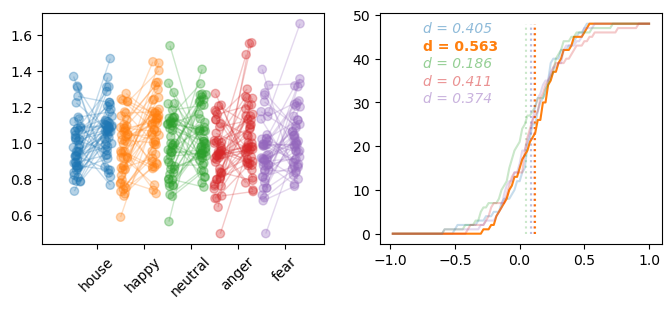

not normalizing
r_precentral ['RH8' 'RH9']


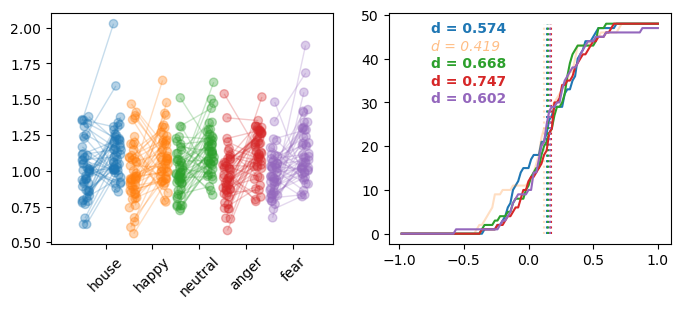

not normalizing
r_lateralorbitofrontal ['RP1' 'RP2']


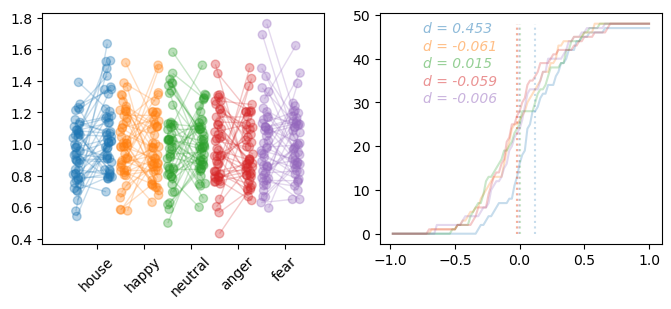

not normalizing
r_insula ['RH2' 'RH3']


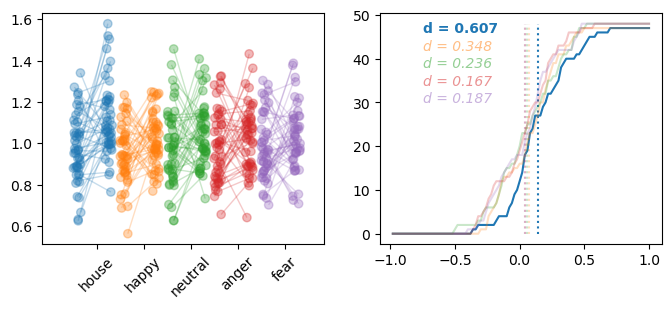

not normalizing
r_hippocampus ['RB2' 'RB3']


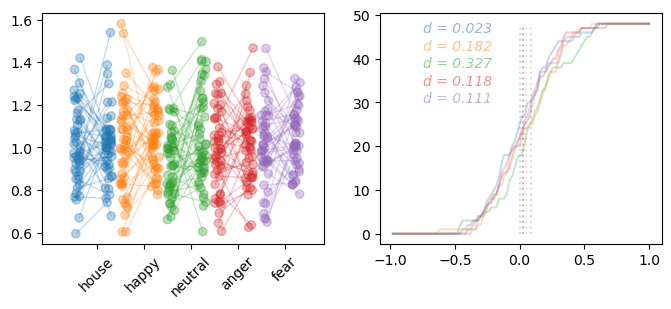

not normalizing
r_parstriangularis ['RO15' 'RO16']


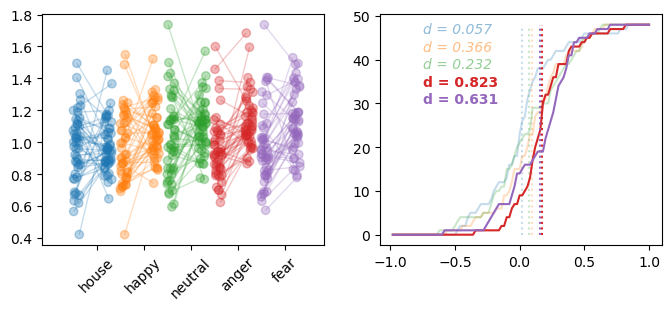

not normalizing
r_supramarginal ['RL15' 'RL16']


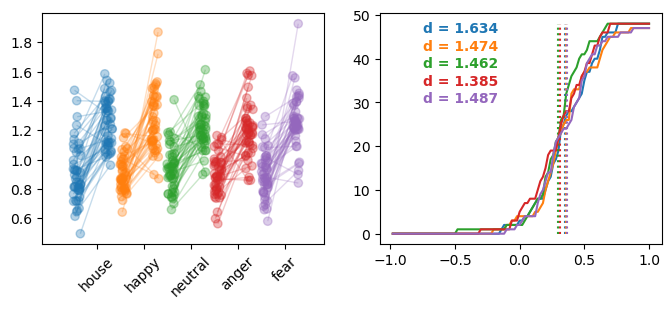

not normalizing
r_middletemporal ['RE10' 'RE9']


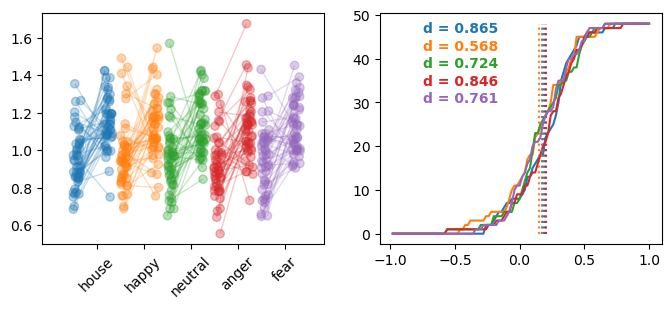

not normalizing
r_middletemporal ['RB10' 'RB11']


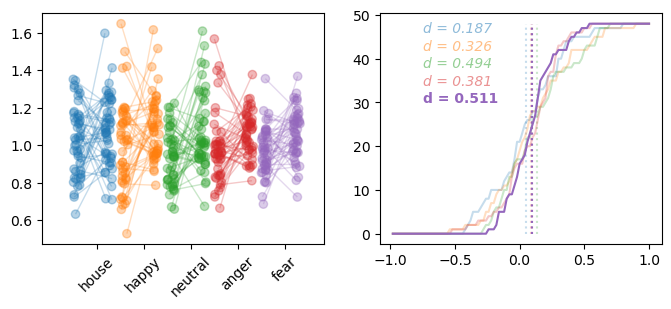

In [94]:
# peak amplitude responsivity seems way too strict - HFB activity is too volatile
# testing looking at mean amplitude above zero, like for peak calculations
from matplotlib.collections import LineCollection
# ERPs or high-frequency broadband activity? (set True for HFB)
HFB_calc = True

# parameters for signal processing
resrate = 1024
# time prior to (pre) and after (post) image onset
pre = -0.5
post = 1
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds

img_cats = ["anger","fear","neutral","happy"]
factors = events.img_category.factorize()
cat_to_num = factors[0]
lcolors = [f"C{val}" for val in cat_to_num]
ns = events.groupby(by="img_category").trial_in_block.count()

pk_params = {"distance": 7,
             "height":0.25,
             "width":16,
             "rel_height":1}

for ii,pair in enumerate(sort_pairs):
    fix,ax = plt.subplots(1,2,figsize=(8,3))
    reg = montage.region[montage.name==pair[0]].item()
    # set plot color
    sys = montage.system[montage.name==pair[0]].item()
    match sys:
        case "sensorimotor":
            c = np.array([0, 88, 111])/255 # dblue
        case "limbic":
            c = np.array([162, 82, 48])/255 # dorange
        case "association":
            c = np.array([74, 79, 85])/255 # dgrey

    # re-reference the signal
    ts,bipolar,_ = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,resrate,norm=None)
    # this could be done outside of the loop for the first pair, set for all subsequent
    t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
    plot_ts = np.linspace(pre,post,t_ixs.shape[1])
    # image onset
    ix0 = min(np.where(plot_ts>=-0.1)[0]) # setting slightly negative b/c some regions ramp 
    # # this is just the first timepoint - shouldn't need
    # ixA = min(np.where(plot_ts>=-0.50)[0])
    # restrict to 667 ms post onset (not sure if I really want this anymore or not...)
    ixB = min(np.where(plot_ts>=0.667)[0])
    # identify and mask noise
    # see how many trials have amplitude excursions within the ERP window
    norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)
    amp_mask = norm_env>MAD_thresh
    # filter the trials with too many amplitude excursions in the pre/post window
    keep = np.sum(np.int64((amp_mask)[t_ixs]),axis=1)<(min_dur*resrate)
    n_ts = events.loc[keep,:].groupby(by="img_category").block.count()
    # find spikes for filtering
    win = int(resrate/64)
    spike_ixs = find_spikes(bipolar, resrate, t_ixs[keep,:], 10000, win, amp_mask, n_samps=16)
    filt_spikes = sorted(set(np.ravel([np.arange(ix-int(win/2),ix+int(win/2),dtype=int) for ix in spike_ixs])))
    # print(f"Number of spikes: {len(spike_ixs)}")

    base_ixs = np.array(t_ixs[:,:int(2*resrate/3)]-int(2*resrate/3),dtype=int)
    # high frequency broadband calculation
    if HFB_calc:
        HFB = 2*np.log(np.abs(hilbert(filtering.bfilt(bipolar, resrate, 4, [70, 150], "bandpass"))))
        HFB[amp_mask] = np.nan
        HFB[filt_spikes] = np.nan
        signal = gaussian_filter(filtering.zscore(HFB),3)
    
    noise_ts = np.linspace(0,base_ixs.shape[-1]/resrate,base_ixs.shape[-1])
    noisedf = test_calc_resp(signal[base_ixs],pk_args=pk_params)
    respdf = test_calc_resp(signal[t_ixs[:,ix0-64:ixB]],pk_args=pk_params)
    d_trial = respdf.amp-noisedf.amp
    d = d_trial.mean()/d_trial.std()
    
    # plt.hist(d_trial,bins=bins)
    # plt.show()
    x_noise = 1+rng.random(base_ixs.shape[0])*0.25+(cat_to_num*1.5)
    x_resp = x_noise+1
    ax[0].scatter(x_noise,noisedf.amp,edgecolor=lcolors, facecolor=lcolors, alpha=0.33)
    ax[0].scatter(x_resp,respdf.amp, edgecolor=lcolors, facecolor=lcolors, alpha=0.33)
    segments = np.array([[x_noise,x_resp],[noisedf.amp,respdf.amp]]).T
    collection = LineCollection(segments,colors=lcolors,linewidths=1,alpha=0.25)
    ax[0].add_collection(collection)
    ax[0].set_xticks(np.arange(max(cat_to_num)+1)*1.5+1.75, labels=factors[1], rotation=45)
    ax[0].set_xlim([0,9])
    dbins = np.linspace(-1,1,101)
    for ix in range(factors[0].max()+1):
        diffs = d_trial.loc[factors[0]==ix]
        dcat = diffs.mean()/diffs.std()
        if dcat>0.5:
            fweight = "bold"
            alpha = 1.
            falpha = 1
            fstyle = "normal"
        else:
            fweight = "light"
            alpha = 0.25
            falpha = 0.5
            fstyle = "italic"
        counts,bins = np.histogram(d_trial.loc[factors[0]==ix], bins=dbins)
        ax[1].plot(bins[1:], np.cumsum(counts), alpha=alpha)
        ax[1].plot(diffs.mean()*np.ones(2),[0,ns.max()],color=f"C{ix}",ls=":",alpha=alpha)
        ax[1].text(-0.75, ns.max()-2-ix*4, f"d = {np.round(dcat,3)}",
                   color=f"C{ix}",weight=fweight,alpha=falpha,style=fstyle)
        
    print(reg,pair)
    plt.show()
    

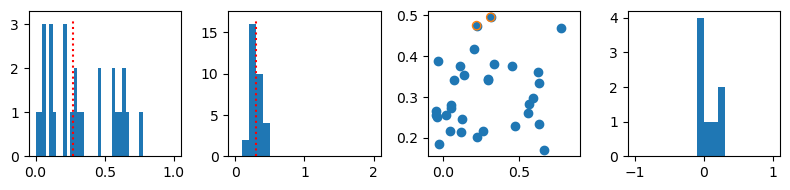

In [7]:
# plot summaries
fig,[ax1,ax2,ax3,ax4] = plt.subplots(1,4,figsize=[8,2], tight_layout=True)
lats = ERP_df.latency
amps = ERP_df.amp
ax1.hist(lats, bins=np.linspace(0,1,41))
ax1.plot(np.ones(2)*lats.mean(),ax1.get_ylim(),"r:")
ax2.hist(np.abs(amps), bins=np.linspace(0,2,21))
ax2.plot(np.ones(2)*amps.mean(),ax2.get_ylim(),"r:")
ax3.scatter(lats,amps,color="C0")
# ax3.scatter(lats,np.abs(amps),facecolor='none',edgecolors="C1")
ax3.scatter(lats[ERP_df.responsive],amps[ERP_df.responsive],facecolor='none',edgecolors="C1")
ax3.set_xlim([-0.1,0.9])
ax4.hist(ERP_df.groupby(by="contacts").agg({"ERP_corr":"mean"}), bins=np.linspace(-1,1,21))
plt.show()

In [ ]:
## OLD - shouldn't need anymore, but keep until confirmed 
# make calculations

# ERPs or high-frequency broadband activity? (set True for HFB)
HFB_calc = True

# parameters for signal processing
resrate = 1024
# time prior to (pre) and after (post) image onset
pre = -0.5
post = 1
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds

img_cats = ["anger","fear","neutral","happy"]
# collect df for each pair for later concatenation
reg_list = []
for pair in pairs_list:
    reg = montage.region[montage.name==pair[0]].item()
    ts,bipolar,filtwins1 = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,
                                                   resrate,norm=None)
    # this could be done outside of the loop for the first pair, set for all subsequent
    t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
    plot_ts = np.linspace(pre,post,t_ixs.shape[1])
    # image onset
    ix0 = min(np.where(plot_ts>=0)[0])
    ixA = min(np.where(plot_ts>=-0.50)[0])
    # restrict to 667 ms post onset
    ixB = min(np.where(plot_ts>=0.667)[0])
    
    # see how many trials have amplitude excursions within the ERP window
    norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)
    amp_mask = norm_env>MAD_thresh
    # 500 ms of baseline
    base_ixs = np.array(t_ixs[:,:int(resrate/2)]-resrate/2,dtype=int)
    # filter the trials with too many amplitude excursions in the pre/post window
    keep = np.sum(np.int64((amp_mask)[t_ixs]),axis=1)<(min_dur*resrate)
    n_ts = events.loc[keep,:].groupby(by="img_category").block.count()
    # find spikes for filtering
    win = int(resrate/64)
    spike_ixs = find_spikes(bipolar, resrate, t_ixs[keep,ixA:ixB], 10000, win, amp_mask, n_samps=16)
    filt_spikes = sorted(set(np.ravel([np.arange(ix-int(win/2),ix+int(win/2),dtype=int) for ix in spike_ixs])))
    print(f"Number of spikes: {len(spike_ixs)}")
    
    if HFB_calc:
        HFB = np.abs(hilbert(filtering.bfilt(bipolar, resrate, 4, [70, 150], "bandpass")))
        HFB[amp_mask] = np.nan
        HFB[filt_spikes] = np.nan
        signal = gaussian_filter(filtering.zscore(HFB),3)

    # normalization factor for ERP max (stdev of ERP baseline)
    basestd = np.nanstd(np.nanmean(signal[base_ixs],axis=0))
    
    # ERP calculations
    fig,ax = plt.subplots(1,len(img_cats),figsize=[8,2], tight_layout=True, sharey=True)
    reg_dfs = []
    avg_ERPs = np.zeros([resrate,len(img_cats)])
    for ix,cat in enumerate(img_cats):
        cat_dict = {}
        ERP_tfilt = np.nanmean(signal[t_ixs[(events.img_category==cat)&(keep),:]],axis=0)
        ERPdf = calc_resp([ERP_tfilt],plot_ts,ix0,ixB,pk_args=None)
        max_1 = ERPdf.max_ix.item()
        pre_1 = ERPdf.pre.item()
        post_1 = ERPdf.post.item()
        if all(np.isnan([max_1,pre_1,post_1])):
            max_1 = 0
            pre_1 = 0
            post_1 = 0
            normamp = 0
            cat_dict["value"] = [normamp,plot_ts[max_1],(post_1-pre_1)/resrate]
        else:
            normamp = ERP_tfilt[max_1]/basestd
            cat_dict["value"] = [normamp,plot_ts[max_1],(post_1-pre_1)/resrate]
    
        ax[ix].set_title(f"{cat}: {round(normamp,2)} ({n_ts.to_dict()[cat]})")
        ax[ix].plot(plot_ts,ERP_tfilt)
        ax[ix].plot(plot_ts[[0,-1]],[0,0],"r:")
        ax[ix].scatter(plot_ts[[pre_1,max_1,post_1]],ERP_tfilt[[pre_1,max_1,post_1]],
                       s=12,color="r",zorder=2)
        
        cat_dict["variable"] = ["normamp","latency","event_dur"]
        reg_dfs.append(pd.DataFrame(cat_dict))
        reg_dfs[ix]["category"] = cat
        # collect the first second of data after image presentation
        # going to use it to make comparisons (how correlated are ERPs)
        avg_ERPs[:,ix] = ERP_tfilt[ix0:(ix0+resrate)] 
        
    ERP_corrs = np.triu(np.corrcoef(avg_ERPs,rowvar=False),k=1)
    pair_corrs = ERP_corrs[np.nonzero(ERP_corrs)].mean()
    print(pair_corrs)
    
    ylims = ax[-1].get_ylim()    
    [ax[ix].plot([0,0],ylims,"r:") for ix in range(len(img_cats))]
    [ax[ix].set_xlim([-0.5,1]) for ix in range(len(img_cats))]
    
    reg_dfs.append(pd.DataFrame({"value":[pair_corrs],"variable":["avgcorr"],"category":["all"]}))
    reg_df = pd.concat(reg_dfs,ignore_index=True)
    reg_df["region"] = reg
    reg_df["contacts"] = pair[1]+"-"+pair[0]
    reg_list.append(reg_df)
    
    fig.suptitle(reg)
    plt.show()

    

ERP_df = pd.concat(reg_list,ignore_index=True)
ERP_df["ID"] = montage.ID.unique()[0]
ERP_df["age"] = montage.age.unique()[0].astype(np.float64)

### trial level comparisons

In [ ]:
# # calculate HFB trial data
# ###########################################
# # only validated on HFB signal! NOT ERP!
# ###########################################

# # parameters for signal processing
# resrate = 1024
# lpfreq = 300
# # time prior to (pre) and after (post) image onset
# pre = -0.5
# post = 1
# # parameters for noise estimation
# win_dur = 0.125 # seconds
# MAD_thresh = 8.0 # median absolute deviations
# min_dur = 0.125 # seconds

# dfs = []
# for pair in pairs_list:
#     reg = montage.region[montage.name==pair[0]].item()
#     ts,signal,filtwins1 = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,
#                                                    resrate,lpfreq=lpfreq,norm=None)

#     # this could be done outside of the loop for the first pair, set for all subsequent
#     t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
#     plot_ts = np.linspace(pre,post,t_ixs.shape[1])
#     # image onset
#     ix0 = min(np.where(plot_ts>=0)[0])
#     # restrict to 50 ms after onset
#     ixA = min(np.where(plot_ts>=0.0)[0])
#     # restrict to 667 ms post onset
#     ixB = min(np.where(plot_ts>=0.667)[0])

#     # see how many trials have amplitude excursions within the ERP window
#     norm_env = spike_utils.envelope_noise_screen(signal, resrate, window_s=win_dur)
#     # filter the trials with too many amplitude excursions in the pre/post window
#     t_mask = np.sum(np.int64((norm_env>MAD_thresh)[t_ixs]),axis=1)<(min_dur*resrate)
    
#     HFB = np.abs(hilbert(filtering.bfilt(signal, resrate, 4, [70,150], "bandpass")))
#     signal = filtering.zscore(HFB)
    
#     sigmat = gaussian_filter(signal,3)[t_ixs]
#     reg_df = calc_resp(sigmat,plot_ts,ixA,ixB,pk_args=None)
#     reg_df["keep"] = t_mask
#     reg_df["region"] = reg
#     reg_df["contacts"] = pair[1]+"-"+pair[0]
#     reg_df["trial"] = np.arange(reg_df.shape[0],dtype=np.int64)
    
#     dfs.append(reg_df)

# trial_df = pd.concat(dfs,ignore_index=True)
# trial_df["ID"] = montage.ID.unique()[0]
# trial_df["age"] = montage.age.unique()[0].astype(np.float64)


In [ ]:
# fig,ax = plt.subplots(1,3,figsize=(6,3), layout="tight")
# rand_pair = rng.choice(trial_df.contacts.unique())
# plot_df = trial_df.loc[(trial_df.contacts==rand_pair)&(trial_df.keep),:]

# print(sum(plot_df.amp.notna()))
# print(plot_df.amp.median())
# ax[0].hist(plot_df.amp, bins=np.linspace(plot_df.amp.min(), plot_df.amp.max(), 25))
# ax[1].hist(plot_df.latency, bins=np.linspace(0, 0.667, 33))
# ax[2].hist(plot_df.duration, bins=np.linspace(0, 0.2, 41))

# fig.suptitle(f"{plot_df.region.unique().item()}")
# plt.show()

### save trial-level (HFB) data

In [ ]:
# # save data
# savestr = fstr+fr"\EmotionTask_{montage.ID.unique()[0]}_TrialData.csv"
# print(savestr)
# trial_df[["ID","age","region","contacts","trial","amp","latency","duration","keep"]].to_csv(savestr,index=False)

### "fancy" ERP plotting

In [ ]:
# hm. do I want to add ERP stuff here? Or just use this for data checks?
# probably just data checks

def plot_ERPs(ERP_mat,imgs,ERP_thresh,plot_ts,ixA,ixB):
    '''
    plot average ERP for each image category
    specify categories (array of strings)
    set threshold for SNR calculation
    use ixA and ixB as integer ixs for finding max/min
    '''

    if "house" in imgs.to_numpy():
        ERP_mat = ERP_mat[imgs!="house",:]
        imgs = imgs[imgs!="house"]
        
    img_cats = imgs.unique()
    img_cats.sort()
    
    fig,ax = plt.subplots(2,len(img_cats),tight_layout=True,figsize=(12,6),
                         sharex=True)
    cmap = plt.cm.grey
    vmin = np.percentile(ERP_mat[~np.isnan(ERP_mat)].flatten(),2.5)
    vmax = np.percentile(ERP_mat[~np.isnan(ERP_mat)].flatten(),97.5)
    xticks = np.linspace(min(plot_ts),max(plot_ts),7)
    yticks = np.round(ax[0,0].get_yticks(),decimals=2)
    pline = np.ones((len(plot_ts),))

    # make a dict of amplitudes and array of avg ERPs
    ERP_amps = {}
    ERPs = np.zeros([len(img_cats),len(plot_ts)])
    # iterate through image categories and plot
    for ix,cat in enumerate(img_cats):
        catmat = ERP_mat[imgs==cat,:]
        ERP = np.nanmean(catmat,axis=0)
        ERPs[ix,:] = ERP
        max_ix = np.argmax(ERP[ixA:ixB])+ixA
        min_ix = np.argmin(ERP[ixA:ixB])+ixA
        
        ax[0,ix].plot(plot_ts,ERP)
        ax[0,ix].set_title(cat)
        ax[0,ix].scatter(plot_ts[max_ix],ERP[max_ix])
        ax[0,ix].scatter(plot_ts[min_ix],ERP[min_ix])
    
        ax[0,ix].fill_between(plot_ts, pline*(-ERP_thresh),
                           pline*(ERP_thresh),
                           color=[0.4,0.4,0.4,0.25]) 
        ax[1,ix].pcolormesh(plot_ts, range(catmat.shape[0]), catmat,
                            cmap=cmap, vmin=vmin, vmax=vmax, shading="nearest")
        
        ERP_amps[cat] = ERP[max_ix] - ERP[min_ix]
   
    # do some axis organization and plot editing   
    [ax[0,ix].set_xticks(xticks,labels=[]) for ix in range(ax.shape[1])]
    ampval = np.max(np.abs(ERPs.flatten()))*1.125
    [ax[0,ix].set_ylim([-ampval,ampval]) for ix in range(ax.shape[1])]
    [ax[0,ix].set_yticklabels([]) for ix in range(1,ax.shape[1])]
    [ax[0,ix].plot([0,0],ax[0,ix].get_ylim(),"r:") for ix in range(ax.shape[1])]
    [ax[1,ix].set_xticks(xticks,labels=[]) for ix in range(ax.shape[1])]
    [ax[1,ix].set_yticks([],labels=[]) for ix in range(ax.shape[1])]
    [ax[1,ix].plot([0,0],ax[1,ix].get_ylim(),"r:") for ix in range(ax.shape[1])]
    
    return ERP_amps,ax

In [ ]:
# parameters for signal processing
resrate = 1024
# time prior to (pre) and after (post) image onset
pre = -0.5
post = 1
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds

img_cats = ["anger","fear","neutral","happy"]

In [ ]:
montage

In [ ]:
##
pair = pairs_list[3]
reg = montage.region[montage.name==pair[0]].item()
print(reg)
ts,bipolar,filtwins1 = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,
                                               resrate,norm=None)

t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
plot_ts = np.linspace(pre,post,t_ixs.shape[1])
# see how many trials have amplitude excursions within the ERP window
norm_env = spike_utils.envelope_noise_screen(bipolar, resrate, window_s=win_dur)
# 500 ms of baseline
base_ixs = np.array(t_ixs[:,:int(resrate/2)]-resrate/2,dtype=int)
# filter the trials with too many amplitude excursions in the pre/post window
t_mask = np.sum(np.int64((norm_env>MAD_thresh)[t_ixs]),axis=1)<(min_dur*resrate)

HFB_calc = True
if HFB_calc:
    HFB = np.abs(hilbert(filtering.bfilt(bipolar, resrate, 4, [70, 150], "bandpass")))
    HFB[norm_env>MAD_thresh] = np.nan
    signal = gaussian_filter(filtering.zscore(HFB),3)
    rms_calc = False
    if rms_calc:
        signal = np.sqrt(filtering.rolling_sum(signal**2/(resrate/32),int(resrate/32)))
        
ERP_tfilt = signal[t_ixs[t_mask,:]]
ERP_thresh = np.nanstd(signal[base_ixs].mean(axis=0))
# reset ixA to image start
ixA = np.argmin(np.abs(plot_ts-0.0))
ixB = np.argmin(np.abs(plot_ts-1))
ERP_amps,ERP_ax = plot_ERPs(ERP_tfilt, events.img_category[t_mask], ERP_thresh,
                            plot_ts, ixA, ixB)
img_cats = np.array(["anger","fear","neutral","happy","house"])

# print(events.loc[t_mask,:].groupby(by="img_category").block.count())

# print(max(abs(np.array([ERP_amps[cat] for cat in img_cats[img_cats!="house"]]))/ERP_thresh))
[ERP_ax[0,ix].set_xlim([pre,post]) for ix in range(ERP_ax.shape[1])]
# [ERP_ax[0,ix].set_ylim([-0.5,1.1]) for ix in range(ERP_ax.shape[1])]
[ERP_ax[0,ix].set_xticks([-0.5,0,0.5], labels=["-0.5","0.0","0.5"]) for ix in range(len(ERP_ax))]
plt.show()

1.7419904700791924
3.2911008769579224 0.03420195439739415 0.2807817589576548


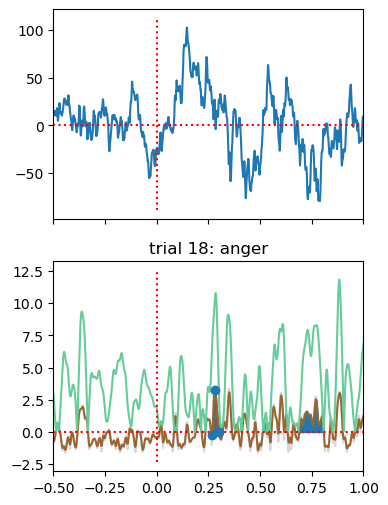

In [44]:
fig,ax = plt.subplots(2,1,figsize=(4,6),sharex=True)
ix = rng.integers(low=0,high=t_ixs.shape[0])
ax[1].plot(np.arange(-0.5,1,1/resrate),filtering.zscore(HFB)[t_ixs[ix,:]].T,
        color=[0.4,0.4,0.4,0.25])

sig = gaussian_filter(filtering.zscore(HFB),3)
rms_sig = np.sqrt(filtering.rolling_sum(sig,int(resrate/32))**2/(resrate/32))[t_ixs[ix,:]]
ixB = min(np.where(plot_ts>=0.75)[0])
[t_ixs[ix,:]]
pk_ixs,pk_info = find_peaks(sig[t_ixs[ix,:ixB]],distance=7,height=max(sig[t_ixs[ix,:(ix0-32)]]*0.5),width=resrate/64,rel_height=1)

maxsum = 0
maxmean = 0
if len(pk_ixs) > 0:
    for ii,pk_ix in enumerate(pk_ixs):
        tsig = sig[t_ixs[ix,:]]
        pre_1, max_1, post_1 = template_extrema(tsig,ixA=ix0,ixB=ixB,max_ix=pk_ix)
        pk_ixs = pk_ixs[sig[pk_ixs]>sig[max_1]]
        # sums
        sumamp = tsig[pre_1:post_1].sum()
        maxsum = max([maxsum,sumamp])
        if sumamp==maxsum:
            sum0 = pre_1
            sum1 = post_1
            summax = np.argmax(tsig[pre_1:post_1])+pre_1

        # means
        meanamp = tsig[pre_1:post_1].mean()
        maxmean = max([maxmean,meanamp])
        if meanamp==maxmean:
            mean0 = pre_1
            mean1 = post_1
            meanmax = np.argmax(tsig[pre_1:post_1])+pre_1
else:
    print('nope')
    sum0 = 0
    sum1 = 0
    summax = 0
    meanmax = 0
    mean0 = 0
    mean1 = 0
    
resp_ixs = [mean0,meanmax,mean1]
print(maxmean)

ax[0].plot(plot_ts,bipolar[t_ixs[ix,:]])
ax[1].scatter(plot_ts[resp_ixs],sig[t_ixs[ix,resp_ixs]],color="C0",zorder=3)
print(sig[t_ixs[ix,meanmax]], plot_ts[mean1]-plot_ts[mean0],plot_ts[meanmax])
ax[1].plot(plot_ts,sig[t_ixs[ix,:]],color=[0.6,0.4,0.2,1])
ax[1].fill_between(plot_ts[sum0:sum1],sig[t_ixs[ix,sum0:sum1]],y2=np.zeros(sum1-sum0),color="C0")
ax[1].fill_between(plot_ts[mean0:mean1],sig[t_ixs[ix,mean0:mean1]],y2=np.zeros(mean1-mean0),color=[0.4,0.4,0.4])
ax[1].set_title(f"trial {ix}: {events.img_category[ix]}")
# ax1 = ax.twinx()
ax[1].plot(plot_ts, rms_sig, color=[0.4,0.8,0.6])
ax[0].set_xlim([-0.50,1])
[ax[ix].plot([0,0], ax[ix].get_ylim(),"r:") for ix in range(ax.shape[0])]
[ax[ix].plot(ax[ix].get_xlim(),[0,0],"r:") for ix in range(ax.shape[0])]
plt.show()

# plt.plot(plot_ts[(mean0-128):(mean1+128)],bipolar[t_ixs[ix,(mean0-128):(mean1+128)]])
# plt.plot(plot_ts[(mean0):(mean1)],bipolar[t_ixs[ix,(mean0):(mean1)]])
# plt.show()

In [ ]:
ts,bpsig,filtwins1 = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,
                                               resrate,norm=None)
plt.plot(bpsig[t_ixs[ix,:]])


In [ ]:
t0 = rng.integers(low=0,high=ERP_tfilt.shape[0]-12)
dt = 4
fig,ax = plt.subplots(1,3,figsize=[9,3])
if HFB_calc:
    mult = 4
else:
    mult = 3
for c in range(len(ax)):
    ax[c].plot(plot_ts,ERP_tfilt[(t0+(dt*c)):(t0+dt+(dt*c)),:].T+np.arange(4)*mult,
               color=[0.2,0.2,0.2,0.75])
    # RMS of the responses
    # ax[c].plot(plot_ts,np.sqrt(filtering.rolling_sum(ERP_tfilt[(t0+(dt*c)):(t0+dt+(dt*c)),:]**2,int(resrate/32),axis=1).T/(resrate/32))+np.arange(4)*mult,
    #            color=[0.2,0.2,0.2,0.75])
    ax[c].plot(plot_ts[[0,-1]],np.ones([2,1])*np.arange(4)*mult, "r:")
    ax[c].plot(np.linspace(-0.25,0.75,5)*np.ones([2,1]),[-mult,4.5*mult],color=[0.6,0.6,0.6,0.33],ls=":")
    ax[c].plot([0,0],[-mult,4.5*mult],"r:")
    ax[c].set_xlim(-0.5,1); ax[c].axis("off")
plt.show()

In [ ]:
# correlate each trial with the ERP for that category type
# this will assess the within-vs-between-category similarity for each trial/category (per region)

# update t_mask to get rid of house trials
t_mask = t_mask & (events.img_category!="house")
# get category labels and index them
cats, label_ix = np.unique(events.img_category[t_mask], return_inverse=True)
# n instances per category
counts = np.bincount(label_ix)

# array of all trials (bad ones masked out)
trials = signal[t_ixs[t_mask,ixA:ixB]]
# calculate the ERPs for each category
ERPs = np.array([trials[label_ix==ix,:].mean(axis=0) for ix in range(len(cats))]).T

# center each matrix
X = trials - trials.mean(axis=1, keepdims=True)
Y = ERPs - ERPs.mean(axis=0, keepdims=True)

# normalize by each trial/ERP's vector norm
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
Y_norm = Y / np.linalg.norm(Y, axis=0, keepdims=True)

# leave one out correlation correctiong
# i.e., calculate category ERPs without individual trials that belong to that category
all_corrs = X_norm @ Y_norm
loo_corrs = all_corrs.copy()
for i, k in enumerate(label_ix):
    # apply leave-one-out correction for trial and matching ERP category
    y_loo = counts[k] * Y[:, k] - X[i]
    y_loo /= np.linalg.norm(y_loo)

    loo_corrs[i, k] = X_norm[i] @ y_loo


In [ ]:
# Ask how similar individual categories are to an average ERP
import matplotlib.colors as mcolors
from scipy.stats import ttest_1samp as tt1

norm = mcolors.Normalize(vmin=0,vmax=1)
cmap = plt.get_cmap("Greys_r")

fig,ax = plt.subplots(len(cats)+1, len(cats)+1, figsize=(6,5))

# TODO: probably want to drop the bad trials here...
matmin = np.percentile(trials[~np.isnan(trials)].flatten(),2.5)
matmax = np.percentile(trials[~np.isnan(trials)].flatten(),97.5)

cbins = np.linspace(-1,1,26)
ymin=0; ymax=0

# going to store T-scores for category comparisons
ttmat = np.zeros((len(cats),len(cats)))
for r,rcat in enumerate(cats):
    # get label index for current category
    lab_ix = np.flatnonzero(cats==rcat).item()
    # trials for that label
    cat_ts = label_ix==lab_ix
    # ERP for that label
    ERP = ERPs[:,lab_ix] # remember, was transposed
    ymin = min([ymin,min(ERP)])
    ymax = max([ymax,max(ERP)])
    # plot the ERP at the end of the current row
    ax[r+1,-1].plot(ERP,"k")
    ax[r+1,-1].plot(ax[r+1,-1].get_xlim(),[0,0],"r:")
    ax[r+1,-1].axis("off")

    # now, across cols in the row, fill in the correlation histograms
    for c,ccat in enumerate(cats):
        # get the label ix for column category
        axix = np.flatnonzero(cats==ccat).item()
        # all trials (instances) of that category
        axcat = label_ix == axix
        # correlations between instances of the column category (axcat) and ERP category [lab_ix]
        ECcorrs = loo_corrs[axcat,lab_ix] 
        fillc = ECcorrs.mean()
        # histogram of correlations between the ERP and current column category trials
        ax[r+1,c].hist(ECcorrs,bins=cbins, weights=(1/sum(axcat)) * np.ones(sum(axcat)),
                         histtype="stepfilled",facecolor=cmap(norm(fillc)), edgecolor=[0.5,0.5,0.5], lw=1.5)
        ax[r+1,c].axis("off")
        ax[r+1,c].plot([0,0],[0,0.25],"r:", zorder=0)
        ax[r+1,c].plot(np.ones(2)*fillc,[0,0.25],"k:")
        
        t_res = tt1(ECcorrs,0,alternative="two-sided").statistic
        ttmat[r,c] = fillc
        ax[r+1,c].text(-1,0.2,f"{round(t_res,2)}", size=9,style='italic')
        if r == 0:
            # cat_ts = groups[ccat]
            ax[r,c].pcolormesh(trials[axcat,:], shading="nearest",
                               cmap=cmap, vmin=matmin, vmax=matmax,)
            ax[r,c].axis("off")

diag = np.eye(ttmat.shape[0], dtype=bool)
n_offs = np.sum(~diag)

[ax[ix,-1].set_ylim(ymin,ymax) for ix in range(1,len(cats))]
[ax[0,ix].set_title(cats[ix]) for ix in range(len(cats))]

ax[0,-1].scatter(rng.normal(size=n_offs)*0.125,ttmat[~diag],s=12, color=[0,0,0,0.5])
ax[0,-1].scatter(rng.normal(size=ttmat.size-n_offs)*0.125,ttmat[diag],s=12,color="r", zorder=0)
ax[0,-1].plot([-1,1],np.ones(2)*ttmat[~diag].mean(),"k:",zorder=0)
ax[0,-1].plot([-1,1],np.ones(2)*ttmat[diag].mean(),"r:",zorder=0)
ax[0,-1].set_xticks([])
ax[0,-1].set_xlim([-1.5,1.5])
ax[0,-1].yaxis.set_label_position("right")
ax[0,-1].yaxis.tick_right()
ax[0,-1].set_ylim([ttmat.min()-(ttmat.max()*0.1),ttmat.max()*1.1])

fig.subplots_adjust(hspace=0.1)

# ax = sns.boxplot(data=corr_df, x="category", y="corr", width=0.3, fill=None, color=[0.4,0.4,0.4], linewidth=1.5)
# sns.swarmplot(data=corr_df, x="category", y="corr",ax=ax)
# ax.plot(ax.get_xlim(),[0,0], "r:")
# ax.set_ylim(-1,1)
# plt.show()

# ax2 = sns.histplot(data=corr_df, y="corr", hue="category", bins=np.linspace(-1,1,26), cumulative=True, stat="probability", element="step", fill=None)
plt.show()

In [ ]:
# ORIGINAL - DON'T EDIT YET...
# Ask how similar individual categories are to an average ERP
import seaborn as sns
import matplotlib.colors as mcolors
from scipy.stats import ttest_1samp as tt1

norm = mcolors.Normalize(vmin=0,vmax=1)
cmap = plt.get_cmap("Greys_r")

groups = events.groupby(by="img_category").indices
groups.pop("house")

img_cats = img_cats[img_cats!="house"]
fig,ax = plt.subplots(len(img_cats)+1, len(img_cats)+1, figsize=(6,5))

matmin = np.percentile(signal[t_ixs[~np.isnan(signal[t_ixs])]].flatten(),2.5)
matmax = np.percentile(signal[t_ixs[~np.isnan(signal[t_ixs])]].flatten(),97.5)

cbins = np.linspace(-1,1,26)
ymin=0; ymax=0

ttmat = np.zeros((len(img_cats),len(img_cats)))
for r,rcat in enumerate(img_cats):
    cat_ts = groups[rcat]
    ERP = signal[t_ixs[cat_ts[t_mask[cat_ts]],ixA:ixB]].mean(axis=0)
    all_corrs = pd.DataFrame(signal[t_ixs[:,ixA:ixB]]).corrwith(pd.Series(ERP),axis=1).to_numpy()
    corr_df = pd.DataFrame.from_dict({"corrs":all_corrs,"category":events.img_category.to_list()})
    corr_df = corr_df.loc[corr_df.category!="house"]
    ymin = min([ymin,min(ERP)])
    ymax = max([ymax,max(ERP)])
    ax[r+1,-1].plot(ERP,"k")
    ax[r+1,-1].plot(ax[r+1,-1].get_xlim(),[0,0],"r:")
    ax[r+1,-1].axis("off")
    for c,ccat in enumerate(img_cats):
        axcat = corr_df.category==ccat
        fillc = np.mean(corr_df.corrs[axcat])
        ax[r+1,c].hist(corr_df.corrs[axcat],bins=cbins, weights=(1/sum(axcat)) * np.ones(sum(axcat)),
                         histtype="stepfilled",facecolor=cmap(norm(fillc)), edgecolor=[0.5,0.5,0.5], lw=1.5)
        ax[r+1,c].axis("off")
        ax[r+1,c].plot([0,0],[0,0.25],"r:", zorder=0)
        ax[r+1,c].plot(np.ones(2)*fillc,[0,0.25],"k:")
        t_res = tt1(corr_df.corrs[axcat],0,alternative="two-sided").statistic
        ttmat[r,c] = fillc
        ax[r+1,c].text(-1,0.2,f"{round(t_res,2)}", size=9,style='italic')
        if r == 0:
            cat_ts = groups[ccat]
            ax[r,c].pcolormesh(signal[t_ixs[cat_ts,ixA:ixB]], shading="nearest",
                               cmap=cmap, vmin=matmin, vmax=matmax,)
            ax[r,c].axis("off")

diag = np.eye(ttmat.shape[0], dtype=bool)
n_offs = np.sum(~diag)

[ax[ix,-1].set_ylim(ymin,ymax) for ix in range(1,len(cats))]
[ax[0,ix].set_title(cats[ix]) for ix in range(len(cats))]

ax[0,-1].scatter(rng.normal(size=n_offs)*0.125,ttmat[~diag],s=20, color=[0,0,0,0.5])
ax[0,-1].scatter(rng.normal(size=ttmat.size-n_offs)*0.125,ttmat[diag],s=20,color="r", zorder=0)
ax[0,-1].plot([-1,1],np.ones(2)*ttmat[~diag].mean(),"k:",zorder=0)
ax[0,-1].plot([-1,1],np.ones(2)*ttmat[diag].mean(),"r:",zorder=0)
ax[0,-1].set_xticks([])
ax[0,-1].set_xlim([-1.5,1.5])
ax[0,-1].yaxis.set_label_position("right")
ax[0,-1].yaxis.tick_right()

fig.subplots_adjust(hspace=0.1)

# ax = sns.boxplot(data=corr_df, x="category", y="corr", width=0.3, fill=None, color=[0.4,0.4,0.4], linewidth=1.5)
# sns.swarmplot(data=corr_df, x="category", y="corr",ax=ax)
# ax.plot(ax.get_xlim(),[0,0], "r:")
# ax.set_ylim(-1,1)
# plt.show()

# ax2 = sns.histplot(data=corr_df, y="corr", hue="category", bins=np.linspace(-1,1,26), cumulative=True, stat="probability", element="step", fill=None)
plt.show()

In [ ]:
diag = np.eye(ttmat.shape[0], dtype=bool)
n_offs = np.sum(~diag)
fig,ax = plt.subplots(1,2,figsize=(3,1.5))
ax[0].pcolormesh(np.flipud(ttmat), vmin=-0.5, vmax=0.5, cmap=cmap)
ax[0].set_xticks([]), ax[0].set_yticks([])
plt.setp(ax[0].spines.values(), lw=2)
ax[1].scatter(rng.normal(size=n_offs)*0.125,ttmat[~diag], color=[0,0,0,0.5])
ax[1].scatter(rng.normal(size=ttmat.size-n_offs)*0.125,ttmat[diag],color="r", zorder=0)
ax[1].plot([-1,1],np.ones(2)*ttmat[~diag].mean(),"k:",zorder=0)
ax[1].plot([-1,1],np.ones(2)*ttmat[diag].mean(),"r:",zorder=0)
ax[1].set_xticks([])
ax[1].set_xlim([-1.5,1.5])
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
plt.show()

In [ ]:
normmat.T.shape

In [ ]:
groups = events.groupby(by="img_category").indices
groups.pop("house")

reorg = np.concat([groups[cat] for cat in groups.keys()])
corrs = np.ma.corrcoef(np.ma.masked_array(signal[t_ixs[reorg,ixA:ixB]],mask=np.isnan(signal[t_ixs[reorg,ixA:ixB]])))
plt.pcolormesh(np.tril(corrs,k=-1), vmin=-1, vmax=1)
plt.show()
# get lower triangles for same image types
ii = 0
for key in groups.keys():
    jj = ii+len(groups[key])
    submat = np.tril(corrs[ii:jj,ii:jj],k=-1)
    print(key,np.nanmean(submat[np.nonzero(submat)]))
    plt.pcolormesh(submat, vmin=-1, vmax=1)
    plt.show()
    ii=jj
    

In [ ]:
t_mask = t_mask & (events.img_category.to_numpy()!="house")
U, S, Vt = np.linalg.svd(signal[t_ixs[t_mask,ixA:ixB]],full_matrices=False)
print(U.shape, S.shape, Vt.shape)
ERP = signal[t_ixs].mean(axis=0)

fig,[ax1,ax2] = plt.subplots(1,2)
ax1.stem(S**2/np.sum(S**2))
cumvar = np.cumsum(S**2/np.sum(S**2))
npcs = np.argmax(np.where(cumvar<=0.9))
print(npcs)
ax2.plot(cumvar),ax2.plot([npcs,npcs],[cumvar[0],cumvar[npcs]],"r:")
plt.show()
plt.plot(plot_ts[ixA:ixB],Vt[0:4,:].T)
# plt.plot(plot_ts,ERP/np.linalg.norm(ERP))
plt.show()

In [ ]:
from scipy.spatial.distance import pdist, squareform
PC_proj = U[:, :npcs] * S[:npcs] # trial coordinates in PC space
D = squareform(pdist(PC_proj, metric="euclidean"))
cats = events.img_category[t_mask].to_numpy()

within = {c: D[np.ix_(cats == c, cats == c)][np.triu_indices((cats == c).sum(), k=1)].mean()
          for c in cats}

centroids = np.vstack([PC_proj[cats == c].mean(axis=0) for c in cats])
centroid_D = squareform(pdist(centroids, metric="euclidean"))

mean_within = np.mean(list(within.values()))
mean_between_centroids = centroid_D[np.triu_indices(len(cats), k=1)].mean()

print("Within-category distances:", within)
print("Mean within-category distance:", mean_within)
print("Between-category centroid distance matrix:\n", centroid_D)
print("Mean between-category centroid distance:", mean_between_centroids)
print("Separation index:", mean_between_centroids - mean_within)


In [ ]:

pairs = [(0, 1), (1, 2), (2, 3)]

fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))

for pix,ax in enumerate(axes):
    for ix,c in enumerate(np.unique(cats)):
        i, j = pairs[pix]
        ax.scatter(PC_proj[cats == c, i], PC_proj[cats == c, j], color=f"C{ix}", alpha=0.7)
        ax.scatter(PC_proj[cats == c, i].mean(), PC_proj[cats == c, j].mean(),
                   marker="X", s=150, color=f"C{ix}", edgecolor="k", zorder=2)
        ax.set_xlabel(f"PC{i+1}")
        ax.set_ylabel(f"PC{j+1}")
        ax.set_title(f"PC{i+1} vs PC{j+1}")

# axes[-1].legend()
plt.tight_layout()
plt.show()


In [ ]:
for ix,c in enumerate(np.unique(cats)):
    plt.scatter(PC_proj[cats == c, 0], PC_proj[cats == c, 2], color=f"C{ix}", alpha=0.7)
    plt.scatter(PC_proj[cats == c, 0].mean(), PC_proj[cats == c, 2].mean(),
               marker="X", s=150, color=f"C{ix}", edgecolor="k", zorder=2)


In [ ]:

test = np.zeros(resrate)
test[int(len(test)/2)] = 1
plt.plot(gaussian_filter(test,3))
plt.stem(test)
plt.xlim([500,525])
plt.show()